# Stylized Facts of Returns: Heavy Tails
#### Scikit-Learn KDE on NVIDIA cuML

### Notebook Outline

**1 · The stylized fact** — returns vs. the normal model (VaR / CAPM / Black-Scholes)
**2 · The data** — intraday returns, 100 large-caps; the bootstrap function
**3 · The headline** — returns vs. the normal model, built up in three layers (normal → +KDE → tails)
**4 · How KDE works** — a kernel bump on every observation, summed; it's built into scikit-learn
**5 · Confidence bands via bootstrap** — the honest CPU baseline, and why it's slow
**6 · The fix: NVIDIA cuML** — one line, same scikit-learn API, runs on the GPU
**7 · CPU vs GPU benchmark** — across sample sizes
**8 · Next steps**

**TL;DR — Run `%load_ext cuml.accel` before your sklearn imports and `sklearn.neighbors.KernelDensity` runs on your NVIDIA GPU.**

The rendering of this notebook is from running it on an AMD Threadripper PRO 7965WX with an NVIDIA RTX PRO 6000 Blackwell.

**The reel tells the conservative version of this story: ~6 minutes on the CPU collapsing to a couple of seconds on the GPU.** The exact GPU time depends on your cuML / driver version — the reel measured about **7 seconds**, and this fresh run on a newer cuML lands faster still (**~1.5 s**); the CPU baseline (**~6 min**) is unchanged. Either way the takeaway is identical: minutes of CPU bootstrapping become seconds on the GPU. Exact numbers (which grow with sample size) are re-measured live below on the real return data.

---

## What this notebook is and isn't

This notebook **is** a Scikit-Learn `KernelDensity` benchmark on a recognizable feature space: the
empirical distribution of intraday equity returns. It compares results and measures runtimes, and it
illustrates a textbook *stylized fact* — that real returns are far more fat-tailed than the normal model.

This notebook **is not:**

- **A trading strategy.** The data is a cross-sectional snapshot of 5-minute returns. There is no
  forecast, no walk-forward, no transaction-cost model. It is for educational purposes.
- **A claim that GPU and CPU produce bit-identical densities.** The kernel evaluation differs
  algorithmically; we check that the density *curves* agree, which is the relevant correctness check.
- **Hardware-portable.** The rendered numbers are specific to a Threadripper PRO 7965WX (24 cores) and an
  RTX PRO 6000 Blackwell. Different hardware will produce different results.

---

## Install NVIDIA cuML and NVIDIA cuDF

```bash
# uv (recommended)
uv pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13

# pip
pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13
```

Requirements: an NVIDIA GPU with CUDA 12+ and a recent driver.
If using **CUDA 12**, change the above dependencies to **cuml-cu12 cudf-cu12**.
The libraries are pre-installed in Google Colab, Kaggle, and Google Colab Enterprise when a GPU is attached.

---

## Hardware Detection

In [1]:
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv,noheader
# CPU model (so the render self-documents the baseline hardware, not just the GPU):
!grep -m1 'model name' /proc/cpuinfo | cut -d: -f2 | sed 's/^ //'

NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 580.105.08, 97887 MiB


AMD Ryzen Threadripper PRO 7965WX 24-Cores


---

# 1. The Stylized Fact — Returns Are Not Normal

**Value-at-Risk, CAPM, and Black-Scholes all model returns the same way: as a normal distribution.**
Real returns are not. They are sharply *leptokurtic* — a tall narrow peak and **heavy tails**: large
moves (gap-ups, gap-downs) happen far more often than a bell curve allows. This is the classic
*stylized fact* of asset returns.

A **kernel density estimate (KDE)** lets us see this directly. It is a non-parametric way to recover
the probability density of a sample **without assuming any distribution** — for each query point it
sums a small kernel (here, a Gaussian) centered on every observation. The shape comes entirely from the
data.

In quant research that shows up everywhere:

- **Tail-risk / VaR** — the normal model badly understates the probability of large moves; a KDE
  recovers the true tail shape from the data.
- **Bootstrap confidence bands** — resample the data hundreds-to-thousands of times and refit to see how
  *stable* the density is. Each resample is an independent KDE fit, so the work multiplies fast.
- **Regime / distribution comparison** — across tickers, sectors, or time windows.

The cost of every one of these scales with *(samples × query-grid)* per fit — exactly the regime where
a GPU pulls away from a CPU.

---

# 2. The Data — Intraday Returns, 100 Large-Caps

**100 large-cap U.S. stocks, 5-minute bar returns** over **Feb 2 – Jun 3, 2026** (~4 months of
regular-session bars), pooled into one sample. Pooling gives a large, heavy-tailed empirical
distribution — exactly the regime where the GPU separation becomes dramatic.

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import time

# Pre-computed 5-minute returns: columns = [ticker, ret]
# (To regenerate from yfinance, see the data/ pipeline in the repo.)
# Works whether the parquet sits next to the notebook or in ../data/.
CANDIDATES = ["intraday_returns.parquet", "../data/intraday_returns.parquet"]
DATA_PATH = next((p for p in CANDIDATES if Path(p).exists()), CANDIDATES[0])

# All figures save under images/; create it once so a fresh / Colab run never
# hits FileNotFoundError on the first savefig.
Path("images").mkdir(parents=True, exist_ok=True)

all_returns = pd.read_parquet(DATA_PATH)
display(all_returns.head())

print(f"{all_returns['ticker'].nunique()} tickers")
print(f"{len(all_returns):,} pooled 5-minute return observations")
print("window: Feb 2 – Jun 3, 2026  (~4 months of regular-session 5-minute bars)")
print(f"mean={all_returns['ret'].mean():.2e}  std={all_returns['ret'].std():.4f}  "
      f"min={all_returns['ret'].min():.3f}  max={all_returns['ret'].max():.3f}")

,ticker,ret
0,AAPL,-0.000169
1,AAPL,0.000506
2,AAPL,-0.000599
3,AAPL,0.000899
4,AAPL,-0.000075


100 tickers
657,396 pooled 5-minute return observations
window: Feb 2 – Jun 3, 2026  (~4 months of regular-session 5-minute bars)
mean=5.18e-06  std=0.0023  min=-0.050  max=0.050


### 2.1 The Bootstrap Function

The confidence band in the headline figure (next section) comes from **bootstrapping**: resample the
returns with replacement and refit the KDE many times, then read a band off the spread of those refits.
One function below does it, used **identically** on CPU and GPU — it returns the timing and the density
curves so we can plot and compare them.

In [3]:
from sklearn.neighbors import KernelDensity

# Bootstrap resamples for the confidence band.
# 100 fits x 50k samples keeps the CPU headline tolerable (~6 min); a real analysis
# would push the resample count toward 1,000 (see the benchmark grid in Section 7).
N_BOOT_HEADLINE = 100      # fits used for the headline CPU-vs-GPU comparison (kept apples-to-apples)
N_BOOT = N_BOOT_HEADLINE   # default resample count; the Section-7 grid overrides this locally
N_SAMPLES = 50_000
KDE_BANDWIDTH = 0.0002


# Fixed evaluation grid: +/- 2% in 5-minute return space.
GRID = np.linspace(-0.02, 0.02, 5000).reshape(-1, 1)

In [4]:
# Bandwidth: each bootstrap is fit on a resample of n_samples N_SAMPLES
# Silverman's rule h = 1.06 * sigma * n**(-1/5) with sigma ~ 0.0023 gives ~2.8e-4 at
# n=N_SAMPLES (and ~1.7e-4 on the full pooled n=657k). We use a slightly tighter fixed
# 2e-4 so the sharp peak is not over-smoothed; the tail shape (the point of the demo)
# is insensitive to this choice across 1e-4..3e-4.


def bootstrap_kde(returns, n_samples=N_SAMPLES, n_boot=N_BOOT, bandwidth=KDE_BANDWIDTH, seed=0):
    """Bootstrap KDE of a return sample. Returns timing + density band."""
    # rng = np.random.default_rng(seed)
    densities = np.empty((n_boot, len(GRID)))

    t0 = time.perf_counter()
    for i in range(n_boot):
        # sample = rng.choice(returns, size=n_samples, replace=True).reshape(-1, 1)
        sample = returns.sample(n=n_samples, replace=True).values.reshape(-1, 1) # cuDF
        kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian").fit(sample)
        densities[i] = np.exp(kde.score_samples(GRID))
    fit_seconds = time.perf_counter() - t0

    return {
        "fit_seconds": fit_seconds,
        "n_samples": n_samples,
        "n_boot": n_boot,
        "mean": densities.mean(axis=0),
        "lo": np.percentile(densities, 5, axis=0),
        "hi": np.percentile(densities, 95, axis=0),
    }

In [5]:
# ~6 minutes for 100 bootstrap fits on the CPU

# One bootstrap KDE fit on the CPU, purely to draw the headline figure below.
# (The *timed* CPU-vs-GPU comparison comes later, in Sections 5-6 - we deliberately do
# NOT load the GPU accelerator yet, so those baseline timings stay honest.)
cpu_run = bootstrap_kde(all_returns['ret'], n_samples=N_SAMPLES, n_boot=N_BOOT_HEADLINE, bandwidth=KDE_BANDWIDTH)
print(f"headline KDE: {cpu_run['fit_seconds']:.2f}s ({cpu_run['n_boot']} fits x {cpu_run['n_samples']:,} samples)")

headline KDE: 366.00s (100 fits x 50,000 samples)


---

# 3. Returns vs. the Normal Model

We build the figure one layer at a time: the normal model, then the empirical distribution, then the difference between them.

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis

plt.style.use("dark_background")
NV_GREEN, NV_BLUE, BAD_RED, AMBER = "#76b900", "#5eaeff", "#ff5e5e", "#ffb84d"

# Shared plot data (grid + the headline bootstrap result, reused by all three figures).
# headline_run was computed just above on the CPU purely to draw this figure; the
# timed CPU-vs-GPU comparison comes later (Sections 5-6).
_run = cpu_run
g = GRID.ravel()
g_pct = g * 100
mu = all_returns['ret'].mean()
sigma = all_returns['ret'].std()
gaussian = norm.pdf(g, loc=mu, scale=sigma)
mean, lo, hi = _run["mean"], _run["lo"], _run["hi"]
ratio = mean / np.clip(gaussian, 1e-300, None)

# Where do the empirical tails exceed the normal model the most? (the Beat 3 callout)
# Restrict to the region where the empirical density is still real signal (>= 0.1% of
# its peak). At the far +/-2% grid edge the matched-normal density underflows toward 0,
# so the raw ratio explodes to a meaningless ~1e13 — a numerical artifact, not a fact.
SIGNAL_FLOOR = mean.max() * 1e-3
tail_mask = (np.abs(g_pct) > 0.5) & (mean > SIGNAL_FLOOR)
tail_mult = ratio[tail_mask].max()
# Guard-rail: if this ever reads in the millions+, the un-floored grid-edge artifact
# has leaked in (e.g. from a stale namespace) — fail loudly rather than ship "44e12x".
assert tail_mult < 1e6, f"tail_mult={tail_mult:,.0f} is the grid-edge underflow artifact, not a market fact"
print(f"In the tails, moves are up to {tail_mult:,.0f}x more frequent than the normal model allows.")

In the tails, moves are up to 3,352x more frequent than the normal model allows.


### 3.1 The normal model (what VaR / CAPM / Black-Scholes assume)

A single red bell curve, matched to the **mean** and **standard deviation** of the real returns. This is how
**Value-at-Risk, CAPM, and Black-Scholes** all picture returns.

> mu = all_returns.**mean**()  
> sigma = all_returns.**std**()  

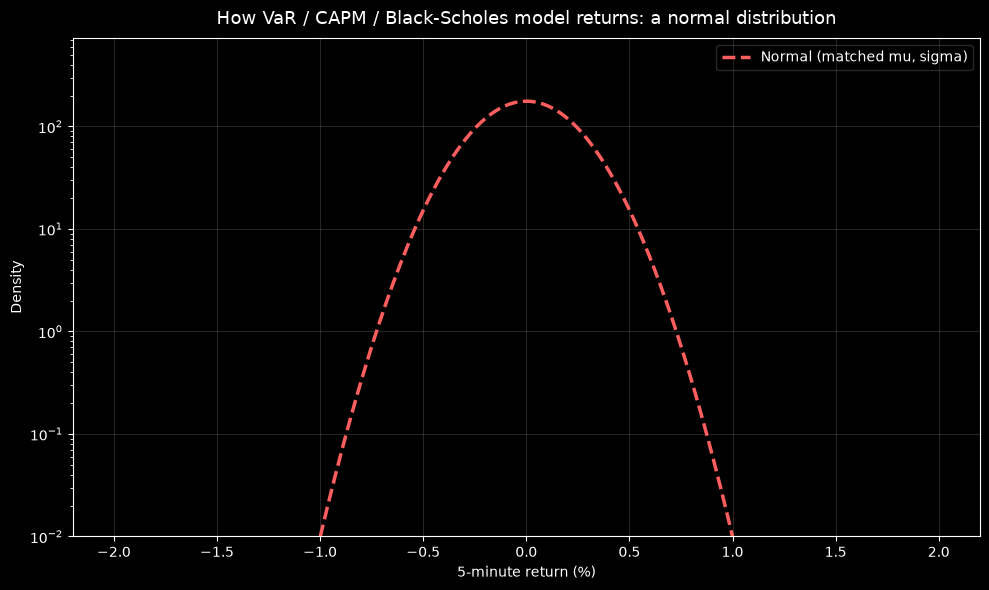

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(g_pct, gaussian, color=BAD_RED, lw=2.5, ls="--", label="Normal (matched mu, sigma)")
ax.set_yscale("log")
ax.set_ylim(0.01, mean.max() * 2)
ax.set_xlabel("5-minute return (%)")
ax.set_ylabel("Density")
ax.set_title("How VaR / CAPM / Black-Scholes model returns: a normal distribution", fontsize=13, pad=10)
ax.legend(loc="upper right", framealpha=0.2)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("images/density_step1_normal.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### 3.2 Add the real distribution (KDE)

Now overlay the **actual** return distribution — the same returns, estimated with Kernel Density
Estimation, with its 5-95% bootstrap confidence band. Tall sharp peak, and tails that refuse to come
down to the red curve.

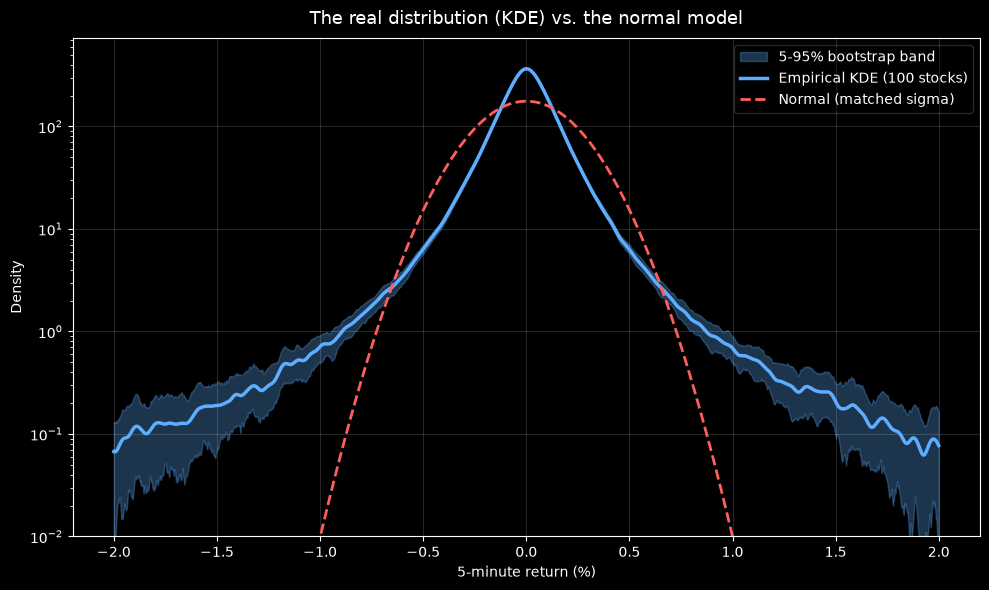

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(g_pct, lo, hi, color=NV_BLUE, alpha=0.30, label="5-95% bootstrap band")
ax.plot(g_pct, mean, color=NV_BLUE, lw=2.5, label="Empirical KDE (100 stocks)")
ax.plot(g_pct, gaussian, color=BAD_RED, lw=2, ls="--", label="Normal (matched sigma)")
ax.set_yscale("log")
ax.set_ylim(0.01, mean.max() * 2)
ax.set_xlabel("5-minute return (%)")
ax.set_ylabel("Density")
ax.set_title("The real distribution (KDE) vs. the normal model", fontsize=13, pad=10)
ax.legend(loc="upper right", framealpha=0.2)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("images/density_step2_kde.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### 3.3 The difference — the heavy tails

The bottom panel is **empirical / normal**: how many times more (or less) often each move actually
happens versus what the bell curve predicts. The two tails — **left (gap-downs)** and **right
(gap-ups)** — are the moves a normal distribution treats as nearly impossible, where blow-ups live.
VaR, CAPM, and Black-Scholes are all blind to them.

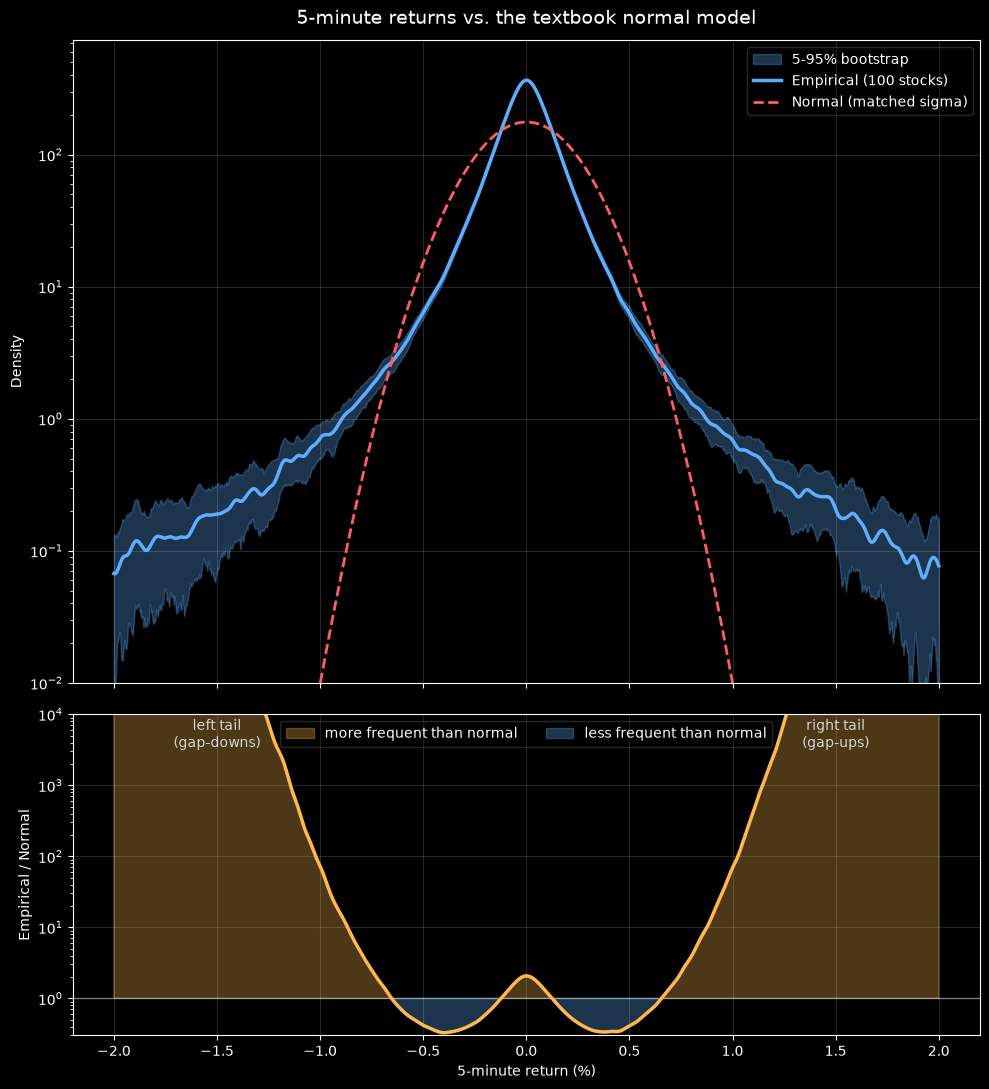

Excess kurtosis: 58.5   (normal = 0)
Largest move:    22.1 sigma   (a normal world makes this effectively impossible)
Tail moves up to 3,352x more frequent than the normal model allows.


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

# Top: density on a log scale so the tails are visible.
ax1.fill_between(g_pct, lo, hi, color=NV_BLUE, alpha=0.30, label="5-95% bootstrap")
ax1.plot(g_pct, mean, color=NV_BLUE, lw=2.5, label="Empirical (100 stocks)")
ax1.plot(g_pct, gaussian, color=BAD_RED, lw=2, ls="--", label="Normal (matched sigma)")
ax1.set_yscale("log")
ax1.set_ylim(0.01, mean.max() * 2)
ax1.set_ylabel("Density")
ax1.legend(loc="upper right", framealpha=0.2)
ax1.set_title("5-minute returns vs. the textbook normal model", fontsize=14, pad=12)
ax1.grid(alpha=0.15)

# Bottom: empirical / normal ratio, with left/right tail callouts.
ax2.axhline(1, color="white", lw=1, alpha=0.4)
ax2.plot(g_pct, ratio, color=AMBER, lw=2.5)
ax2.fill_between(g_pct, 1, ratio, where=(ratio > 1), color=AMBER, alpha=0.3,
                 label="more frequent than normal")
ax2.fill_between(g_pct, 1, ratio, where=(ratio < 1), color=NV_BLUE, alpha=0.3,
                 label="less frequent than normal")
ax2.annotate("left tail\n(gap-downs)", xy=(-1.5, min(ratio[g_pct < -1.5].max(), 9e3)),
             color="white", fontsize=10, ha="center", va="top", alpha=0.8)
ax2.annotate("right tail\n(gap-ups)", xy=(1.5, min(ratio[g_pct > 1.5].max(), 9e3)),
             color="white", fontsize=10, ha="center", va="top", alpha=0.8)
ax2.set_yscale("log")
ax2.set_ylim(0.3, 1e4)
ax2.set_ylabel("Empirical / Normal")
ax2.set_xlabel("5-minute return (%)")
ax2.legend(loc="upper center", framealpha=0.2, ncol=2)
ax2.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("images/intraday_density_ratio.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

# Headline stylized-fact numbers.
exc_kurt = kurtosis(all_returns["ret"], fisher=True)
max_sigma = np.abs(all_returns["ret"]).max() / sigma
print(f"Excess kurtosis: {exc_kurt:.1f}   (normal = 0)")
print(f"Largest move:    {max_sigma:.1f} sigma   "
      f"(a normal world makes this effectively impossible)")
print(f"Tail moves up to {tail_mult:,.0f}x more frequent than the normal model allows.")

---

# 4. How KDE Builds That Curve

No bell curve assumed, no formula imposed. KDE places a small **bump (a kernel)** on every single
observation, then **adds them up**. Dense clusters of returns stack into peaks; rare extreme moves
still get their own bump out in the tails — which is exactly why the heavy tails survive.

The toy example below uses a handful of points so you can see the individual bumps and their sum.

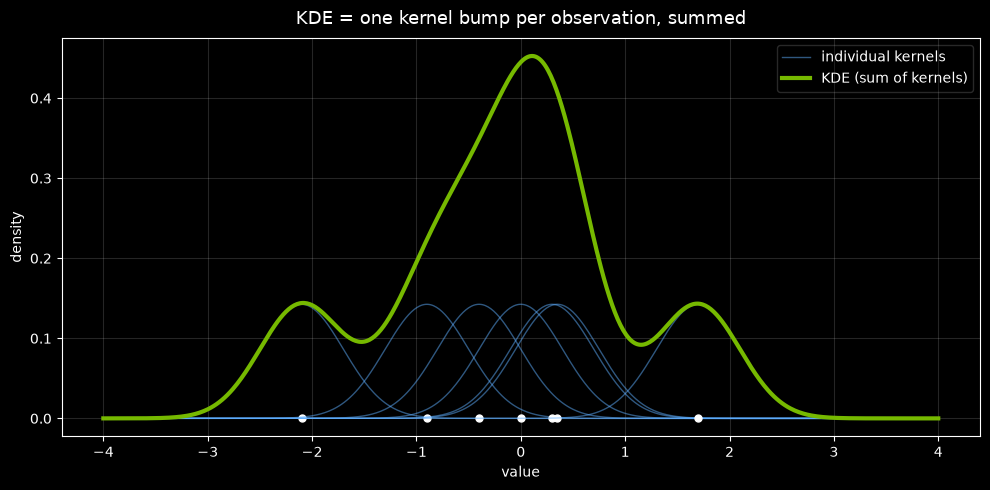

In [10]:
# Toy illustration: individual Gaussian kernels (thin) summing to the KDE (thick).
from sklearn.neighbors import KernelDensity as _KD

toy = np.array([-2.1, -0.9, -0.4, 0.0, 0.3, 0.35, 1.7])   # a few sample "returns"
bw = 0.4
xs = np.linspace(-4, 4, 600)

fig, ax = plt.subplots(figsize=(10, 5))

# Each observation's own kernel bump.
for j, x0 in enumerate(toy):
    bump = norm.pdf(xs, loc=x0, scale=bw) / len(toy)
    ax.plot(xs, bump, color=NV_BLUE, lw=1, alpha=0.5,
            label="individual kernels" if j == 0 else None)
    ax.plot([x0], [0], marker="o", color="white", ms=5)

# The KDE = sum of the bumps (via sklearn, so it matches the real method).
kde = _KD(bandwidth=bw, kernel="gaussian").fit(toy.reshape(-1, 1))
dens = np.exp(kde.score_samples(xs.reshape(-1, 1)))
ax.plot(xs, dens, color=NV_GREEN, lw=3, label="KDE (sum of kernels)")

ax.set_title("KDE = one kernel bump per observation, summed", fontsize=13, pad=10)
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.legend(loc="upper right", framealpha=0.2)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("images/kde_kernels_explainer.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### KDE is built into scikit-learn

The exact estimator used here is [`sklearn.neighbors.KernelDensity`](https://scikit-learn.org/stable/modules/density.html#kernel-density-estimation)
— no extra library for the method itself. The only thing we add for speed is `cuml.accel` (next).

### Confidence Bands via Bootstrap — and the CPU Problem

The shaded band in the headline figure came from **bootstrapping**: resample the returns with
replacement and refit the KDE many times. Here we run that bootstrap as a timed, honest baseline
**before loading any GPU accelerator**. Each resample is a full `KernelDensity` fit, so the cost is
`N_BOOT_HEADLINE` independent fits back-to-back — **a couple of minutes** at this setting
(100 fits × 50,000 samples), and far longer once you push the resample count up toward a thousand.

---

# 5. CPU Benchmark Grid

While we are still on the CPU, sweep the sample size so we have a full baseline to compare against the
GPU. The speedup grows with the workload, so we want the whole curve, not a single point.

KDE fit time is **linear in the number of bootstraps**, so to keep the CPU baseline from taking 20+
minutes at the largest sample size we time a reduced `CPU_BOOT` and linearly scale to the full
`N_BOOT`. **To keep that scaling honest we also run one fully-measured CPU point at `N_BOOT`** (the
smallest sample) as an anchor — the scaled and measured numbers should agree.

> **The grid uses the same real pooled returns as the density plot** (`all_returns`), so the timing
> reflects the actual market data, not a synthetic stand-in. The GPU grid in Section 7 runs the full
> `N_BOOT` directly on the same data.

In [11]:
SCALES = [10_000, 50_000, 100_000, 200_000]
N_BOOT = 1_000              # the workload the GPU grid runs in full
CPU_BOOT = 100             # CPU timed on fewer bootstraps, then scaled (time is linear in n_boot)


def time_sweep(pool, scales, n_boot, label, scale_to=None):
    """Time a KDE bootstrap sweep on the REAL return pool.
    If scale_to is set, linearly extrapolate fit time to that n_boot."""
    out = {}
    print(f"{label} grid ({n_boot} bootstraps"
          + (f", scaled to {scale_to})" if scale_to else ")") + ":")
    for n in scales:
        measured = bootstrap_kde(pool, n_samples=n, n_boot=n_boot)["fit_seconds"]
        out[n] = measured * (scale_to / n_boot) if scale_to else measured
        print(f"  n={n:>7,}: {out[n]:7.2f}s")
    return out


# CPU grid on the real pooled returns (scaled from CPU_BOOT -> N_BOOT).
cpu_grid = time_sweep(all_returns["ret"], SCALES, CPU_BOOT, "CPU", scale_to=N_BOOT)

# Honesty anchor: one FULLY-MEASURED CPU point at the full N_BOOT (smallest sample,
# so it is cheap). The scaled estimate above should match this within a few percent.
anchor_n = SCALES[0]
anchor_measured = bootstrap_kde(all_returns["ret"], n_samples=anchor_n, n_boot=N_BOOT)["fit_seconds"]
print(f"\nanchor (measured, full N_BOOT={N_BOOT}, n={anchor_n:,}): {anchor_measured:6.2f}s")
print(f"anchor (scaled  from CPU_BOOT={CPU_BOOT}):              {cpu_grid[anchor_n]:6.2f}s")
print(f"scaling error: {abs(anchor_measured - cpu_grid[anchor_n]) / anchor_measured:.1%}"
      "  (small -> linear-in-n_boot scaling is valid)")

CPU grid (100 bootstraps, scaled to 1000):


  n= 10,000:  284.17s


  n= 50,000: 3634.08s


  n=100,000: 8402.08s


  n=200,000: 18880.49s



anchor (measured, full N_BOOT=1000, n=10,000): 285.54s
anchor (scaled  from CPU_BOOT=100):              284.17s
scaling error: 0.5%  (small -> linear-in-n_boot scaling is valid)


---

# 6. The Fix — NVIDIA cuML (CUDA-X for Machine Learning)

The fix is one line and **needs no rewrite and no new API**. `cuml.accel` — part of **NVIDIA cuML**,
the open-source **CUDA-X for Machine Learning** library — patches Scikit-Learn so supported estimators
dispatch to the GPU. Load it, re-import `KernelDensity`, and the **exact same code** runs on the GPU.

> **Same scikit-learn API, no rewrites.** cuML is pre-installed in Google Colab and Kaggle — just attach
> a GPU. Or install it yourself (see the install cell near the top).

### 6.1 Load `cuml.accel`

Load it, then re-import `KernelDensity` so the patched class is picked up.

> In a real session you would load this **before** your first sklearn import and run the whole notebook
> on GPU. Here we load it *after* the CPU run so we can measure both in one pass.

In [12]:
%load_ext cudf.pandas

In [13]:
%load_ext cuml.accel
# ~ OR ~
# %reload_ext cuml.accel


# If not in IPython / notebook:
#   import cuml.accel; cuml.accel.install()
#
# If you cannot change the code, run any script on GPU with:
#   python -m cuml.accel your_script.py



# Re-import so the cuml.accel-patched KernelDensity is used.
from sklearn.neighbors import KernelDensity

import pandas as pd # also GPU accelerated via cudf.pandas

### 6.2 GPU Run — Same Code, Now on the GPU

Exactly the same `bootstrap_kde()` call. Nothing changed but the one `%load_ext` line above — the same
bootstrap workload now runs on the GPU in a fraction of the time.

In [14]:
all_returns = pd.read_parquet(DATA_PATH)

# Headline GPU run: SAME fit count as the CPU headline (cpu_run) so the speedup is
# apples-to-apples. The Section-7 grid rebinds the global N_BOOT to 1,000; we pin this
# headline to N_BOOT_HEADLINE so that local override can never leak into this number.
gpu_run = bootstrap_kde(all_returns["ret"], n_samples=N_SAMPLES, n_boot=N_BOOT_HEADLINE)
print(f"GPU bootstrap KDE: {gpu_run['fit_seconds']:.2f}s "
      f"({gpu_run['n_boot']} fits x {gpu_run['n_samples']:,} samples)")

GPU bootstrap KDE: 1.56s (100 fits x 50,000 samples)


### 6.3 GPU Speedup

Same 100 bootstrap fits on each side, so this is an apples-to-apples ratio. The reel quotes a conservative **~6 min → ~7 s** (the GPU time when the video was recorded); on the current cuML this run is faster still, so the ratio printed below is on the high side. Read the *story* — **minutes → seconds** — as the headline, not any single multiple: the exact number tracks whatever cuML / driver / GPU you run on and is not bit-identical run-to-run.

In [15]:
speedup = cpu_run["fit_seconds"] / gpu_run["fit_seconds"]
print(f"CPU:     {cpu_run['fit_seconds']:7.2f}s")
print(f"GPU:     {gpu_run['fit_seconds']:7.2f}s")
print(f"Speedup: {speedup:7.1f}x")

CPU:      366.00s
GPU:        1.56s
Speedup:   234.7x


### 6.4 Correctness Check — the density curves agree

GPU and CPU do not produce bit-identical numbers, but the recovered **density curves** should overlay.
We check the max absolute difference relative to the peak density.

In [16]:
rel_diff = np.abs(cpu_run["mean"] - gpu_run["mean"]).max() / cpu_run["mean"].max()
# Print in scientific notation: the difference is tiny but NONZERO (GPU and CPU are not
# bit-identical), and :.3% would round it to a misleading "0.000%".
print(f"max relative difference between CPU and GPU density: {rel_diff:.2e}")
assert rel_diff < 0.05, "CPU and GPU densities diverge more than expected"
print("OK — CPU and GPU densities agree.")

max relative difference between CPU and GPU density: 1.15e-03
OK — CPU and GPU densities agree.


---

# 7. CPU vs GPU Benchmark — Across Sample Sizes

The full CPU-versus-GPU benchmark for scikit-learn's KDE across sample sizes. We timed the CPU grid in
Section 5.1 (before the accelerator was loaded) on the **real pooled returns**; now that `cuml.accel`
is active we run the **same sweep on the same data on the GPU** and compare. **The larger the data, the
more the GPU outperforms the CPU** — small samples are dominated by overhead, large samples are where
the GPU pulls away.

### 7.1 GPU Grid

`cuml.accel` is loaded in Section 6, so the identical `time_sweep` now runs on the GPU.

In [17]:
gpu_grid = time_sweep(all_returns['ret'], SCALES, N_BOOT, "GPU")   # full N_BOOT on real returns — fast on GPU

GPU grid (1000 bootstraps):


  n= 10,000:    4.46s


  n= 50,000:   13.98s


  n=100,000:   25.57s


  n=200,000:   48.73s


### 7.2 Wall-Clock and Speedup

The speedup grows with sample size (more data per fit = more work to parallelize), so on this rig it ranges from tens× at 10K samples to a few-hundred× at 200K. These are measured on a single machine, depend on your cuML / driver / GPU, and are not bit-identical run-to-run. The point isn't a specific multiple — it's that a multi-minute CPU sweep finishes in seconds on the GPU.

In [18]:
import json

bench = pd.DataFrame({
    "n_samples": SCALES,
    "cpu_s": [cpu_grid[n] for n in SCALES],
    "gpu_s": [gpu_grid[n] for n in SCALES],
})
bench["speedup"] = bench["cpu_s"] / bench["gpu_s"]
print(bench.to_string(index=False))

# Persist for the reel chart (matches 02-lw-turnover's lw_timings_*.json convention).
Path("kde_timings.json").write_text(json.dumps({
    "scales": SCALES,
    "cpu_s": [cpu_grid[n] for n in SCALES],
    "gpu_s": [gpu_grid[n] for n in SCALES],
    "hardware": "Threadripper PRO 7965WX + RTX PRO 6000 Blackwell",
}, indent=2))
print("\nSaved kde_timings.json")

 n_samples        cpu_s     gpu_s    speedup
     10000   284.165444  4.460067  63.713267
     50000  3634.079052 13.975205 260.037615
    100000  8402.078113 25.571869 328.567226
    200000 18880.486951 48.727879 387.467860

Saved kde_timings.json


### 7.3 Benchmark Visual

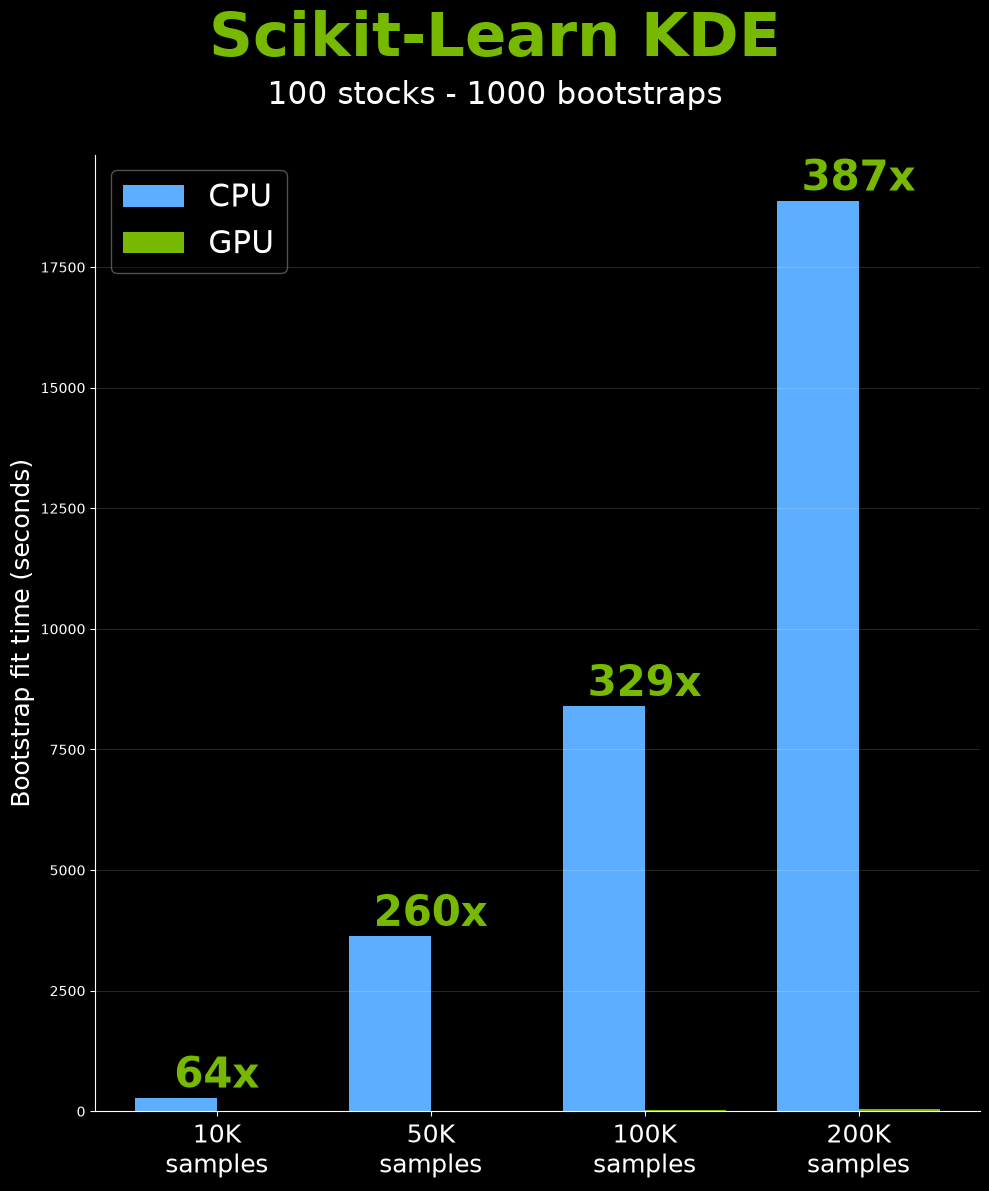

In [19]:
labels = ["10K", "50K", "100K", "200K"]
cpu_t = bench["cpu_s"].to_numpy()
gpu_t = bench["gpu_s"].to_numpy()
speedups = bench["speedup"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 12), facecolor="black")
ax.set_facecolor("black")
x = np.arange(len(SCALES))
w = 0.38
ax.bar(x - w/2, cpu_t, w, color=NV_BLUE, label="CPU")
ax.bar(x + w/2, gpu_t, w, color=NV_GREEN, label="GPU")
for i, (c, s) in enumerate(zip(cpu_t, speedups)):
    if np.isfinite(s):
        ax.text(i, c, f"{s:.0f}x", ha="center", va="bottom",
                fontsize=30, fontweight="bold", color=NV_GREEN)
ax.set_xticks(x)
ax.set_xticklabels([f"{l}\nsamples" for l in labels], fontsize=18)
ax.set_ylabel("Bootstrap fit time (seconds)", fontsize=18)
ax.legend(fontsize=22, loc="upper left", framealpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.15)
fig.text(0.5, 0.95, "Scikit-Learn KDE", ha="center", fontsize=44, fontweight="bold", color=NV_GREEN)
fig.text(0.5, 0.91, f"100 stocks - {N_BOOT} bootstraps", ha="center", fontsize=22, color="white")
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("images/kde_benchmark.png", dpi=200, facecolor="black", bbox_inches="tight")
plt.show()

---

# 8. Next Steps

- **Try it yourself on Colab / Kaggle.** Attach a GPU, run `%load_ext cuml.accel` at the top, and the
  whole notebook runs on GPU with no other changes. (Colab link in the video description.)
- **Or install cuML yourself:**
  `uv pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13`
- **Scale the bootstrap.** Push `N_BOOT_HEADLINE` up toward a thousand for tight confidence bands — a
  multi-day CPU job becomes a coffee break on the GPU, at the speedups measured in Section 7.
- **Swap the estimator.** The same `%load_ext cuml.accel` line accelerates many other sklearn
  estimators (`PCA`, `KMeans`, `SpectralClustering`, `LedoitWolf`, ...).

*Educational benchmark, not a trading strategy.*